# EDA — CNN/DailyMail

Análisis exploratorio del dataset CNN/DailyMail para resumen automático de textos.
Objetivo: entender distribuciones de longitud, ratios de compresión y validar las
decisiones de `max_input_length` y `max_target_length` antes de entrenar.

In [18]:
# Setup and imports
import sys
from pathlib import Path

# Allow importing from src/ when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_config, load_cnn_dailymail
from src.data.preprocessing import load_tokenizer

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# Load config and dataset
cfg = load_config("../config/config.yaml")
dataset = load_cnn_dailymail(cfg)
dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 1000
    })
})

## 1. Ejemplos representativos

Vamos a inspeccionar algunos pares (artículo, resumen) para entender el estilo de los datos.

In [20]:
# Show a few examples
for i in range(2):
    sample = dataset["train"][i]
    print(f"=== Example {i} ===")
    print(f"ARTICLE ({len(sample['article'].split())} words):")
    print(sample["article"][:500] + "...\n")
    print(f"SUMMARY ({len(sample['highlights'].split())} words):")
    print(sample["highlights"])
    print("\n" + "="*80 + "\n")

=== Example 0 ===
ARTICLE (455 words):
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s...

SUMMARY (41 words):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


=== Example 1 ===
ARTICLE (698 words):
Editor's note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and analyze the stories behind the events. Here, Soledad O'Brien take

## 2. Distribución de longitudes en palabras

Análisis a nivel de palabras (rápido, no requiere tokenizer).

In [21]:
# Build a dataframe with word-level lengths for all splits
def build_length_df(dataset) -> pd.DataFrame:
    """Compute word-level length statistics across all splits."""
    rows = []
    for split_name, split in dataset.items():
        for art, summ in zip(split["article"], split["highlights"]):
            rows.append({
                "split": split_name,
                "article_words": len(art.split()),
                "summary_words": len(summ.split()),
                "compression": len(summ.split()) / max(len(art.split()), 1),
            })
    return pd.DataFrame(rows)

df = build_length_df(dataset)
df.groupby("split").describe().T

split                       test         train   validation
article_words count  1000.000000  20000.000000  1000.000000
              mean    623.025000    596.836400   640.395000
              std     348.820122    319.075728   346.697985
              min      73.000000     18.000000    81.000000
              25%     338.000000    348.000000   357.000000
              50%     566.000000    533.000000   587.000000
              75%     841.500000    792.000000   863.000000
              max    1750.000000   1831.000000  1783.000000
summary_words count  1000.000000  20000.000000  1000.000000
              mean     34.470000     44.433850    34.383000
              std       9.668432      8.978232    10.237535
              min      14.000000     11.000000    10.000000
              25%      27.000000     38.000000    27.000000
              50%      34.000000     45.000000    33.000000
              75%      41.000000     51.000000    41.000000
              max      80.000000     90.000000    76.000000
compression   count  1000.000000  20000.000000  1000.000000
              mean      0.075551      0.098090     0.073522
              std       0.049669      0.062001     0.051077
              min       0.011985      0.014002     0.009340
              25%       0.040936      0.056851     0.038380
              50%       0.060925      0.083106     0.058365
              75%       0.096850      0.124126     0.092954
              max       0.329114      2.111111     0.398438

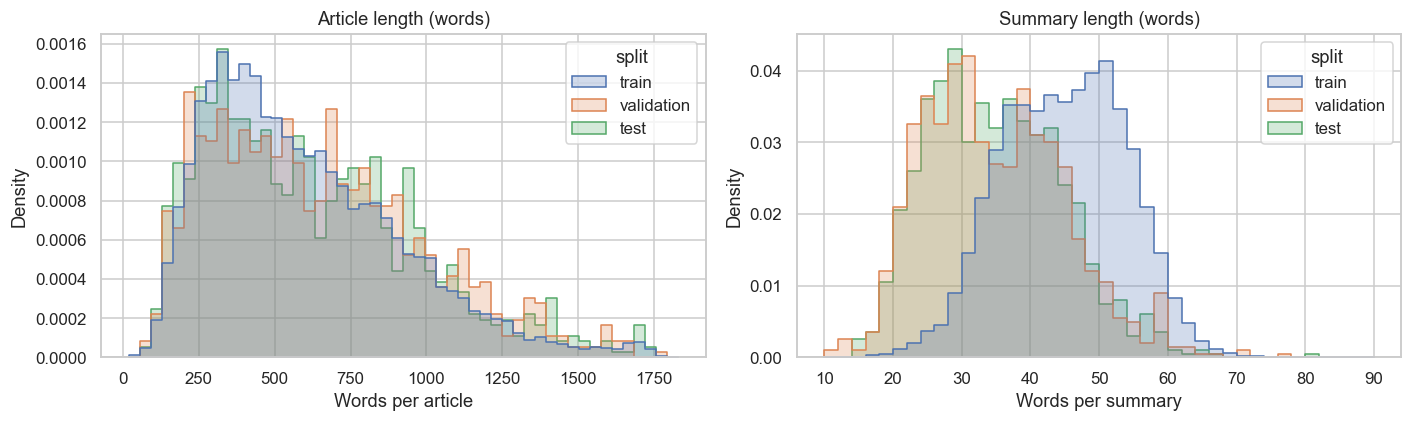

In [22]:
# Length distributions: articles vs summaries
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="article_words", hue="split", bins=50,
             ax=axes[0], element="step", common_norm=False, stat="density")
axes[0].set_title("Article length (words)")
axes[0].set_xlabel("Words per article")

sns.histplot(data=df, x="summary_words", hue="split", bins=40,
             ax=axes[1], element="step", common_norm=False, stat="density")
axes[1].set_title("Summary length (words)")
axes[1].set_xlabel("Words per summary")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "length_distributions_words.png", bbox_inches="tight")
plt.show()

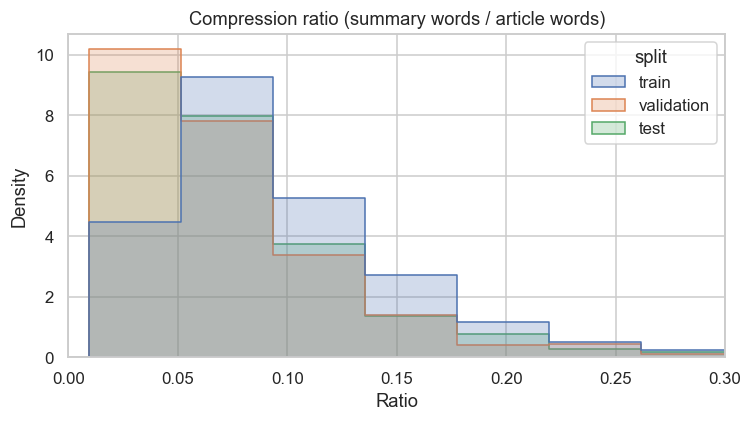

In [23]:
# Compression ratio distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="compression", hue="split", bins=50,
             ax=ax, element="step", common_norm=False, stat="density")
ax.set_title("Compression ratio (summary words / article words)")
ax.set_xlabel("Ratio")
ax.set_xlim(0, 0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_ratio.png", bbox_inches="tight")
plt.show()

## 3. Distribución de longitudes en tokens

Las palabras no son tokens. Cada modelo tokeniza distinto, así que vamos a medir las
longitudes reales con los tokenizers de T5 y Qwen3 para validar `max_input_length`.

In [24]:
# Tokenize a sample of train to estimate real token lengths
SAMPLE_SIZE = 1000
sample_indices = np.random.RandomState(cfg["seed"]).choice(
    len(dataset["train"]), size=SAMPLE_SIZE, replace=False
)
sample = dataset["train"].select(sample_indices)

t5_tok = load_tokenizer(cfg["models"]["t5"]["name"])
qwen_tok = load_tokenizer(cfg["models"]["qwen"]["name"])

def token_lengths(tokenizer, texts):
    """Compute token lengths without padding/truncation."""
    return [len(tokenizer(t, truncation=False)["input_ids"]) for t in texts]

token_df = pd.DataFrame({
    "t5_article": token_lengths(t5_tok, sample["article"]),
    "qwen_article": token_lengths(qwen_tok, sample["article"]),
    "t5_summary": token_lengths(t5_tok, sample["highlights"]),
    "qwen_summary": token_lengths(qwen_tok, sample["highlights"]),
})
token_df.describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors


,t5_article,qwen_article,t5_summary,qwen_summary
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,850.721000,773.236000,66.379000,57.258000
std,462.390571,416.930387,13.963894,12.484202
min,142.000000,130.000000,25.000000,21.000000
25%,497.750000,456.750000,56.000000,48.000000
50%,748.500000,681.500000,66.500000,57.000000
75%,1094.250000,999.000000,76.000000,66.000000
max,2870.000000,2833.000000,128.000000,112.000000


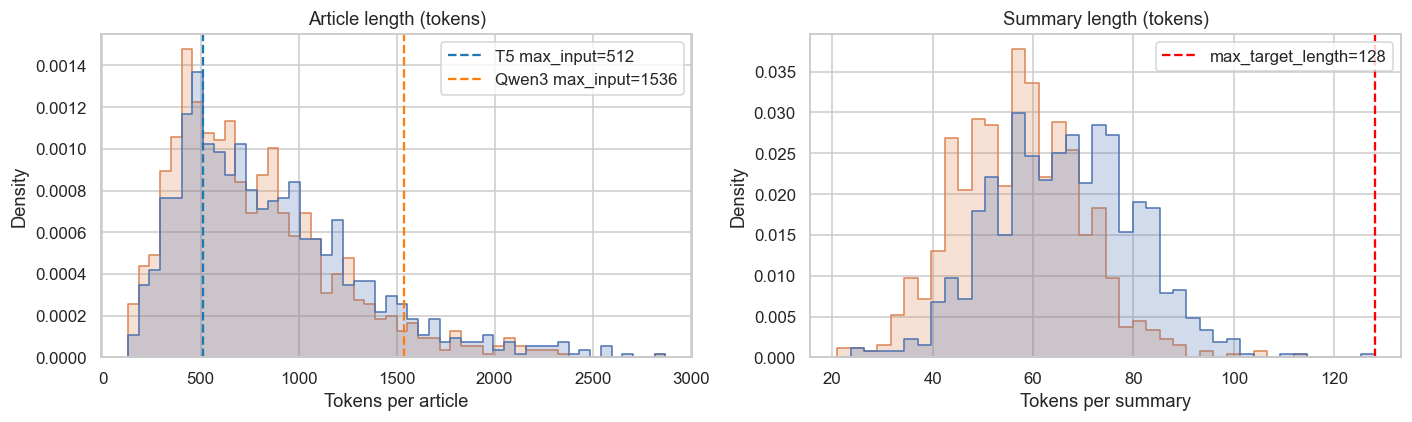

In [25]:
# Compare tokenizers on article length with per-model truncation limits
t5_max_in = cfg["models"]["t5"]["max_input_length"]
qwen_max_in = cfg["models"]["qwen"]["max_input_length"]
max_target = cfg["dataset"]["max_target_length"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(token_df[["t5_article", "qwen_article"]], bins=50,
             element="step", ax=axes[0], stat="density", common_norm=False)
axes[0].axvline(t5_max_in, color="tab:blue", linestyle="--",
                label=f"T5 max_input={t5_max_in}")
axes[0].axvline(qwen_max_in, color="tab:orange", linestyle="--",
                label=f"Qwen3 max_input={qwen_max_in}")
axes[0].set_title("Article length (tokens)")
axes[0].set_xlabel("Tokens per article")
axes[0].legend()

sns.histplot(token_df[["t5_summary", "qwen_summary"]], bins=40,
             element="step", ax=axes[1], stat="density", common_norm=False)
axes[1].axvline(max_target, color="red", linestyle="--",
                label=f"max_target_length={max_target}")
axes[1].set_title("Summary length (tokens)")
axes[1].set_xlabel("Tokens per summary")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "length_distributions_tokens.png", bbox_inches="tight")
plt.show()

In [26]:
# Truncation analysis with per-model limits
t5_max_in = cfg["models"]["t5"]["max_input_length"]
qwen_max_in = cfg["models"]["qwen"]["max_input_length"]
max_target = cfg["dataset"]["max_target_length"]

truncation_stats = pd.DataFrame({
    "Model": ["Flan-T5-large", "Qwen3-1.7B"],
    "max_input_length": [t5_max_in, qwen_max_in],
    "Articles truncated (%)": [
        (token_df["t5_article"] > t5_max_in).mean() * 100,
        (token_df["qwen_article"] > qwen_max_in).mean() * 100,
    ],
    "Summaries truncated (%)": [
        (token_df["t5_summary"] > max_target).mean() * 100,
        (token_df["qwen_summary"] > max_target).mean() * 100,
    ],
})
truncation_stats

,Model,max_input_length,Articles truncated (%),Summaries truncated (%)
0,Flan-T5-large,512,73.0,0.0
1,Qwen3-1.7B,1536,5.6,0.0


## 4. Conclusiones del EDA

- **Tamaño de los artículos:** la media ronda las ~600 palabras y los picos llegan a ~1.800.
  En tokens, esto se traduce en valores algo mayores dependiendo del tokenizer.
- **Resúmenes:** muy concisos (35-45 palabras), con compresión agresiva (5-7%).
- **Decisión sobre `max_input_length`:** revisar la tabla de truncación. Si más del
  10-15% de artículos se trunca, considerar subir a 1536.
- **Decisión sobre `max_target_length`:** 128 tokens cubre virtualmente todos los resúmenes.
- **Diferencias entre tokenizers:** Qwen3 y T5 producen distinto número de tokens para el
  mismo texto. Esto importa para comparaciones justas de eficiencia.

## 5. Decisión sobre max_input_length por modelo

El análisis de tokenización revela dos hallazgos clave:

1. **T5 tokeniza ~10% más tokens que Qwen3 para el mismo texto**, debido a la menor
   eficiencia de su tokenizer SentencePiece frente al BPE moderno de Qwen3.
2. **La mediana de los artículos (~700-750 tokens) excede el límite nativo de T5 (512)**,
   lo que implica truncación severa para este modelo.

Dado que cada arquitectura tiene límites de contexto distintos, se configura
`max_input_length` por modelo en lugar de globalmente:

| Modelo        | max_input_length | % artículos truncados (estimado) |
|---------------|------------------|----------------------------------|
| Flan-T5-large | 512              | ~70%                             |
| Qwen3-1.7B    | 1536             | ~5-8%                            |
| BART-large    | 1024             | ~29%                             |
| Pegasus       | 1024             | ~29%                             |

Esta decisión refleja las limitaciones arquitectónicas reales de cada modelo y será
uno de los ejes del análisis comparativo: el impacto del tamaño de ventana de contexto
en una tarea donde la entrada supera frecuentemente los límites clásicos.